In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dataset = pd.read_csv('diabetes.csv')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
import os
os.makedirs('figures', exist_ok=True)

In [3]:
dataset.dropna()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
# zeros in these columns are medically impossible — they represent missing data
# Pregnancies=0 is a valid value so it stays
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
dataset[zero_cols].eq(0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Insulin is the worst — 374 zeros, nearly half the dataset. SkinThickness has 227. these aren't actually 0, they're just missing. replacing them with NaN.

In [5]:
dataset[zero_cols] = dataset[zero_cols].replace(0, np.nan)

In [6]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(dataset, test_size=.2,
                                       stratify=dataset['Outcome'],
                                       random_state=42)

Objective: classify whether a patient has diabetes from 8 clinical measurements.

In [7]:
y_train = train_set[['Outcome']]
x_train = train_set.drop(columns=['Outcome'])

y_test = test_set[['Outcome']]
x_test = test_set.drop(columns=['Outcome'])

x_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,1,90.0,62.0,12.0,43.0,27.2,0.580,24
711,5,126.0,78.0,27.0,22.0,29.6,0.439,40
373,2,105.0,58.0,40.0,94.0,34.9,0.225,25
46,1,146.0,56.0,NaN,NaN,29.7,0.564,29
682,0,95.0,64.0,39.0,105.0,44.6,0.366,22


In [8]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 614 entries, 353 to 107
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    int64  
 1   Glucose                   610 non-null    float64
 2   BloodPressure             591 non-null    float64
 3   SkinThickness             439 non-null    float64
 4   Insulin                   324 non-null    float64
 5   BMI                       605 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 43.2 KB


In [9]:
x_train.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,614.000000,610.000000,591.000000,439.000000,324.000000,605.000000,614.000000,614.000000
mean,3.819218,121.701639,72.145516,29.059226,149.077160,32.448926,0.477428,33.366450
std,3.314148,30.099771,12.512061,10.519221,107.234748,6.874773,0.330300,11.833438
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.084000,21.000000
25%,1.000000,99.000000,64.000000,21.000000,76.000000,27.600000,0.245000,24.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.382500,29.000000
75%,6.000000,140.750000,80.000000,36.000000,183.500000,36.600000,0.639250,41.000000
max,17.000000,199.000000,122.000000,99.000000,744.000000,67.100000,2.329000,81.000000


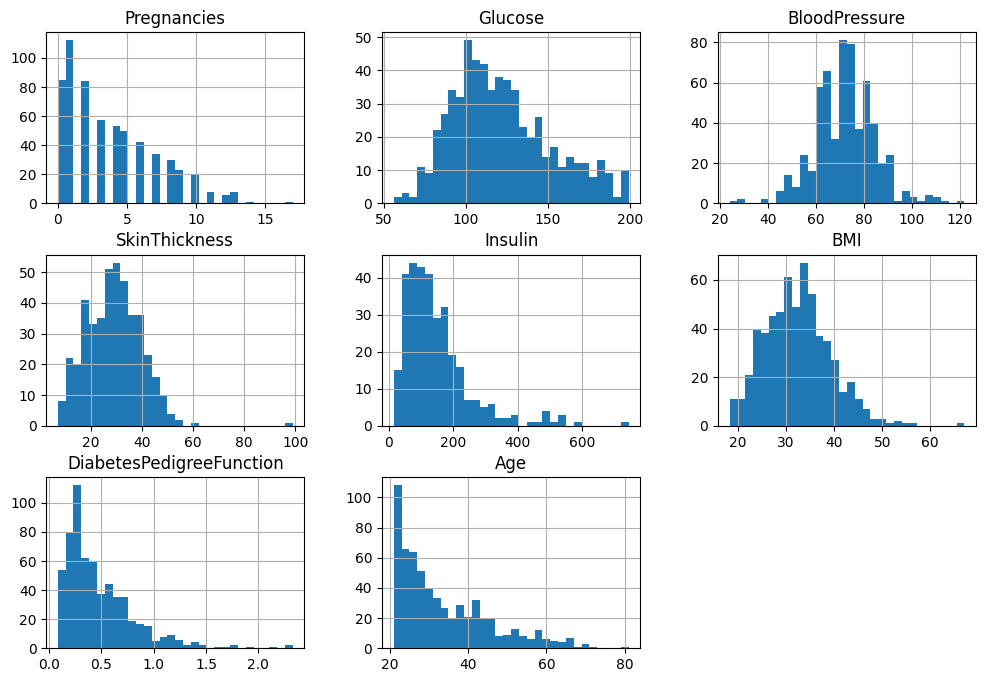

In [10]:
x_train.hist(bins=30, figsize=(12, 8))
plt.savefig('figures/diabetes_feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

Glucose and BMI look roughly normal after the zeros are gone. Insulin is still heavily right skewed even then — a lot of extreme values. Age and Pregnancies both skew right.

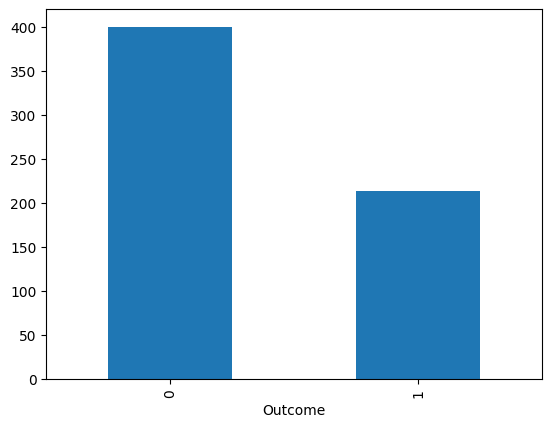

In [11]:
train_set['Outcome'].value_counts().plot(kind='bar')
plt.savefig('figures/diabetes_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

about 35% positive cases. skewed but not so bad that we need resampling.

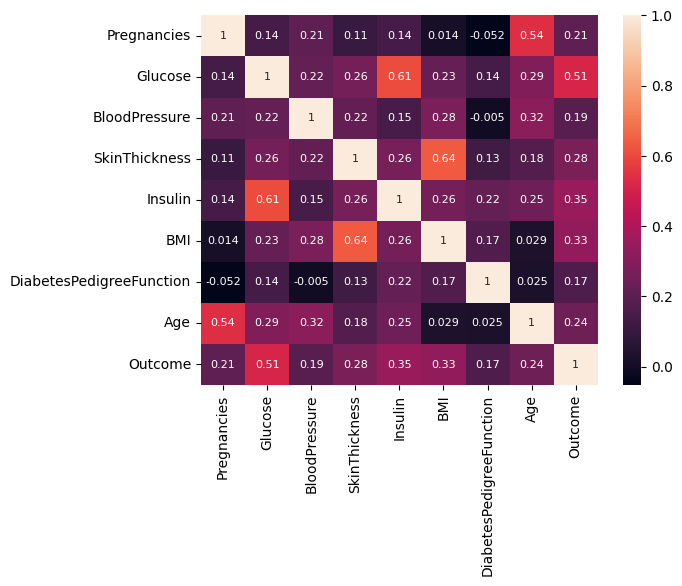

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = x_train.select_dtypes(include='number').columns

df = x_train[numeric_cols].copy()
df['Outcome'] = y_train

sns.heatmap(df.corr(), annot=True, annot_kws={'size': 8})
plt.savefig('figures/diabetes_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Glucose is the strongest predictor by a wide margin. BMI and Age are next but a good bit weaker. Insulin and SkinThickness barely register — probably because of how much data is missing for both.

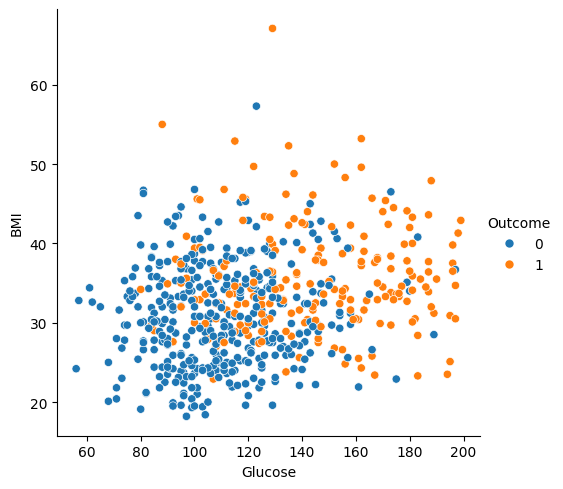

In [13]:
df = x_train.copy()
df['Outcome'] = np.ravel(y_train)

g = sns.relplot(data=df, x='Glucose', y='BMI', hue='Outcome')
g.savefig('figures/diabetes_glucose_bmi_scatter.png', dpi=150, bbox_inches='tight')

high glucose + high BMI tends to go diabetic but there's a lot of overlap in the middle. not a clean split.

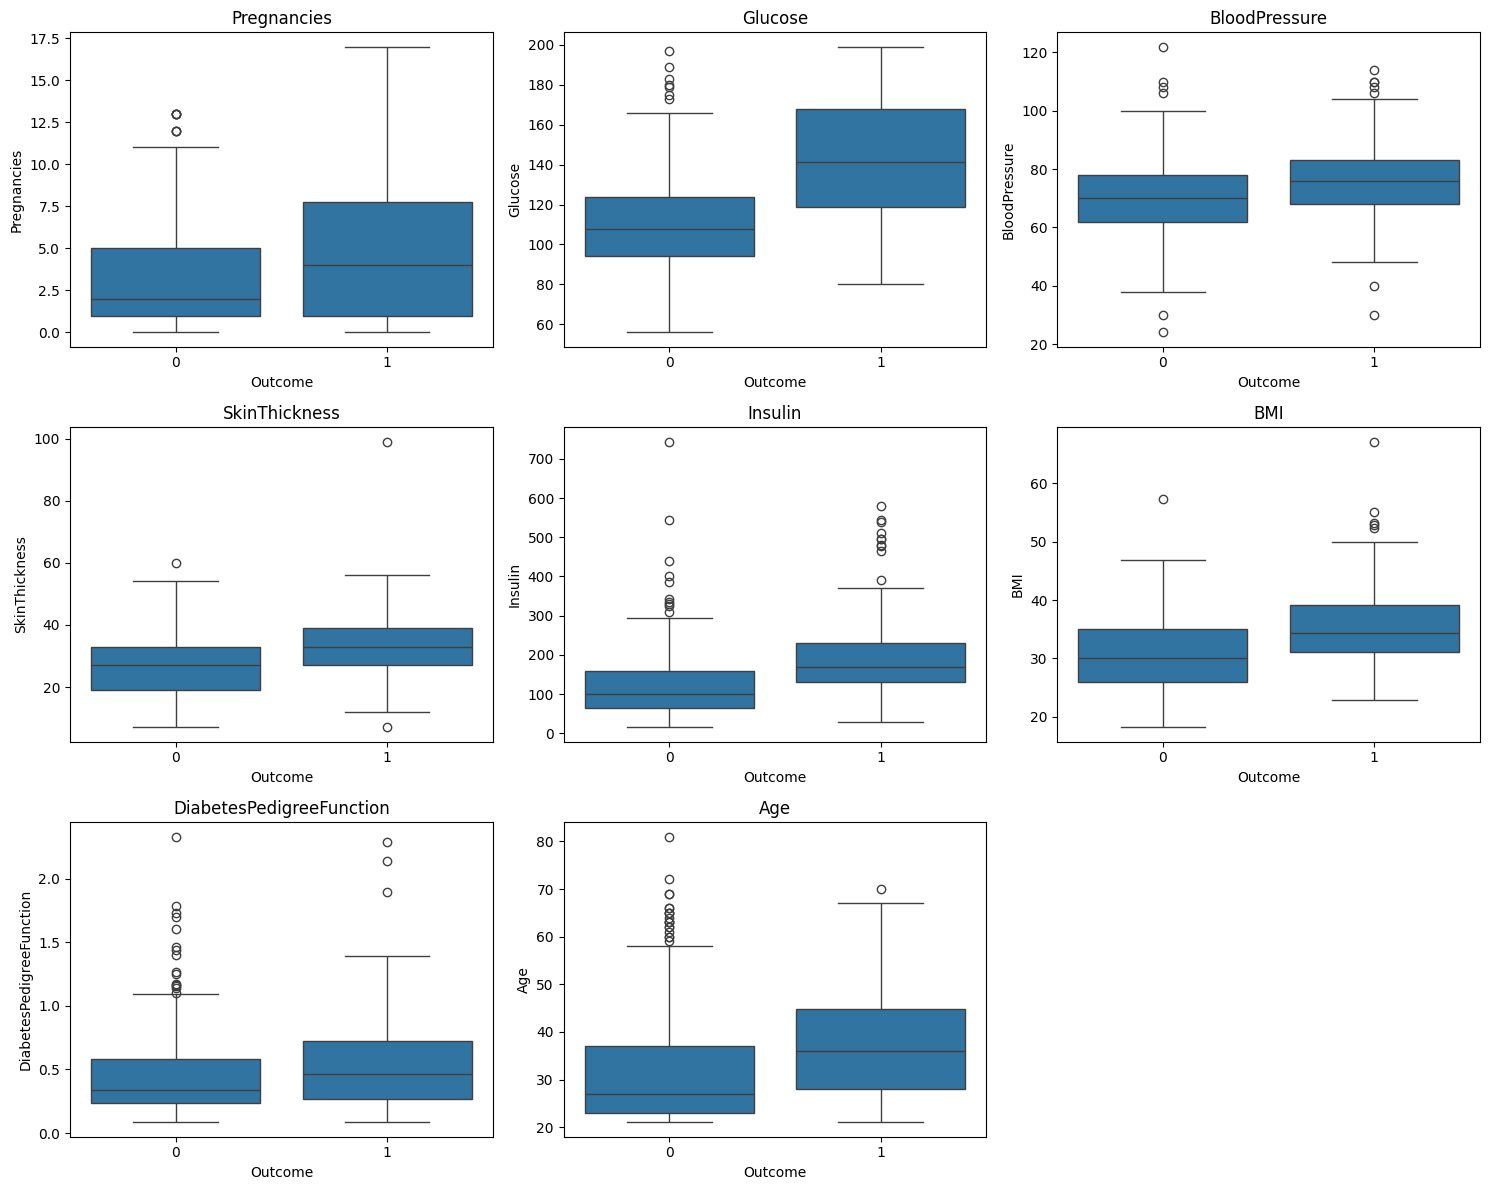

In [14]:
import math

df = x_train.copy()
df['Outcome'] = np.ravel(y_train)

n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Outcome', y=col, ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('figures/diabetes_boxplots_by_outcome.png', dpi=150, bbox_inches='tight')
plt.show()

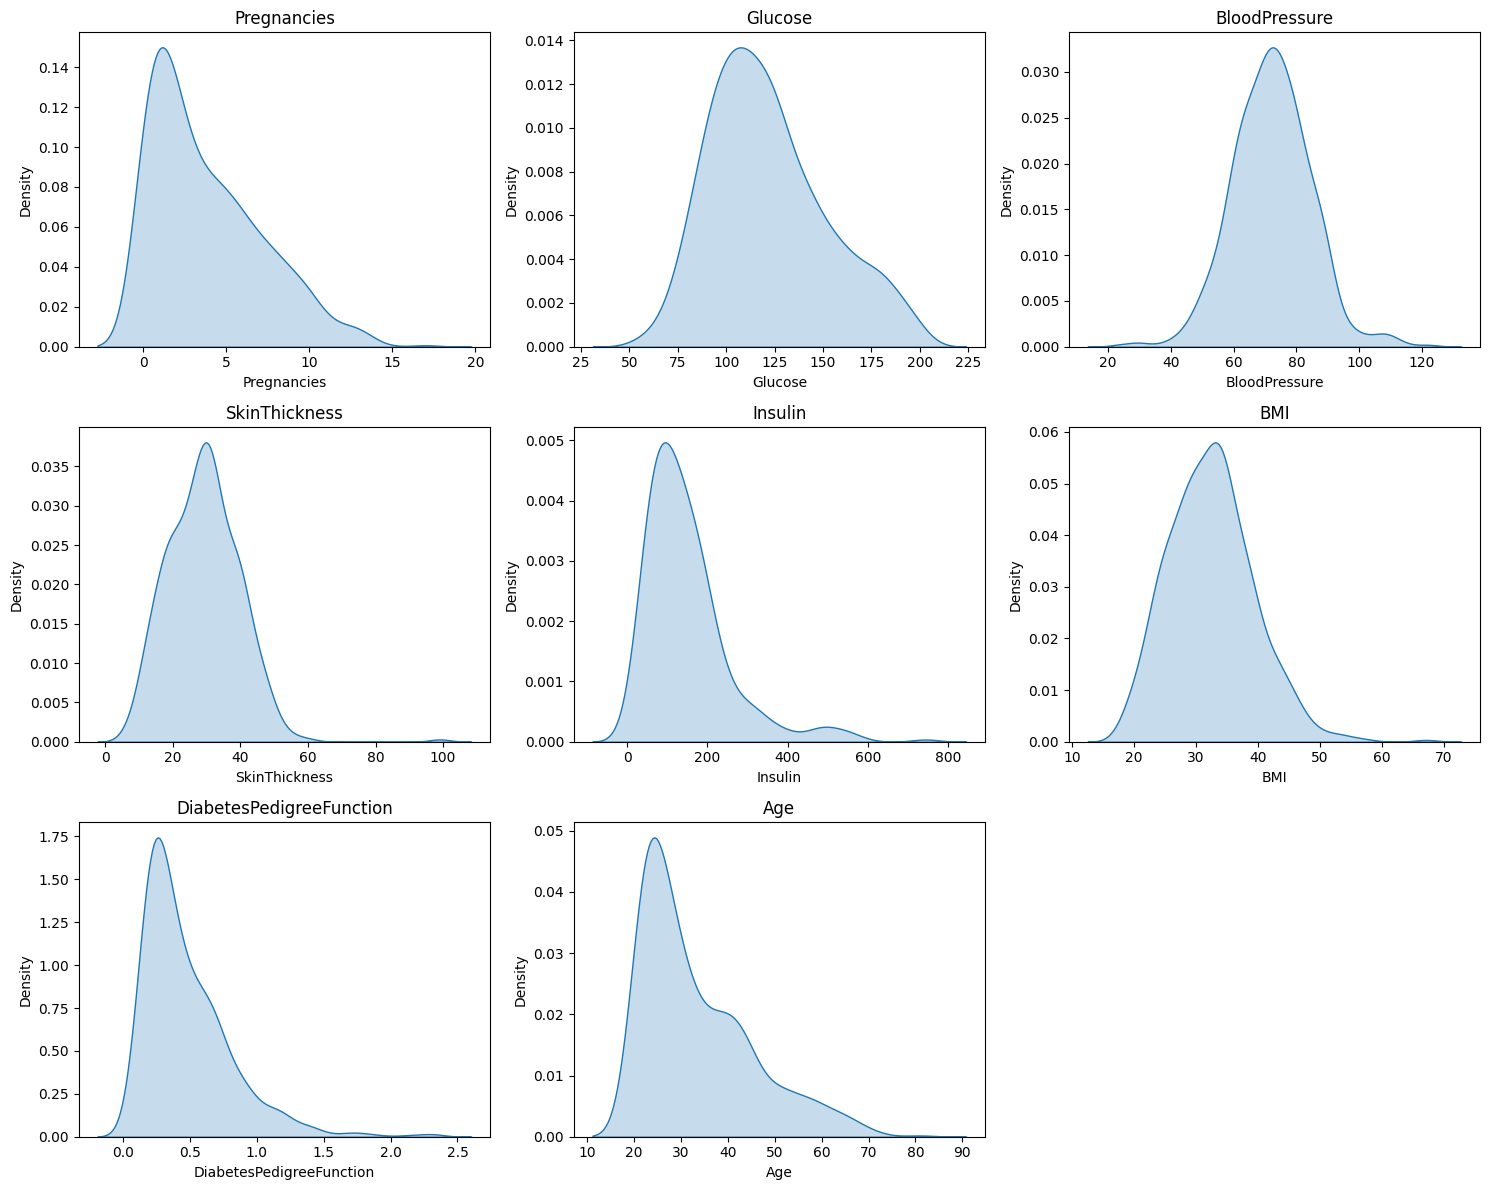

In [15]:
n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=train_set, x=col, ax=ax, fill=True)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('figures/diabetes_kde_plots.png', dpi=150, bbox_inches='tight')
plt.show()

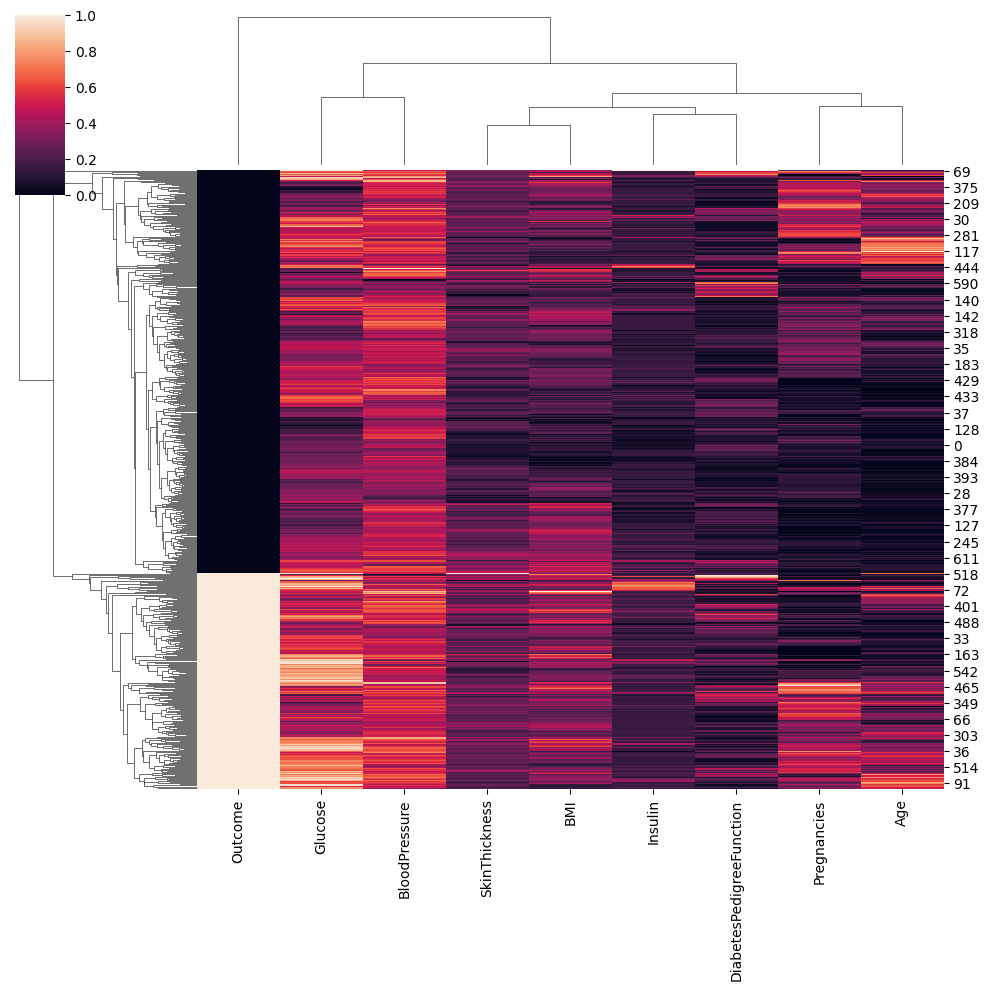

In [16]:
from sklearn.impute import SimpleImputer

# impute before clustermap since it cant handle NaN
numeric_cols_full = train_set.select_dtypes(include='number').columns
X_imp = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(train_set[numeric_cols_full]),
    columns=numeric_cols_full
)

g = sns.clustermap(X_imp, standard_scale=1)
g.savefig('figures/diabetes_clustermap.png', dpi=150, bbox_inches='tight')

Notes from this:
Glucose clusters closest to Outcome by a clear margin.
Insulin and SkinThickness cluster together and are most distant from Outcome — consistent with how much data is missing for both.
DiabetesPedigreeFunction sits mostly on its own.

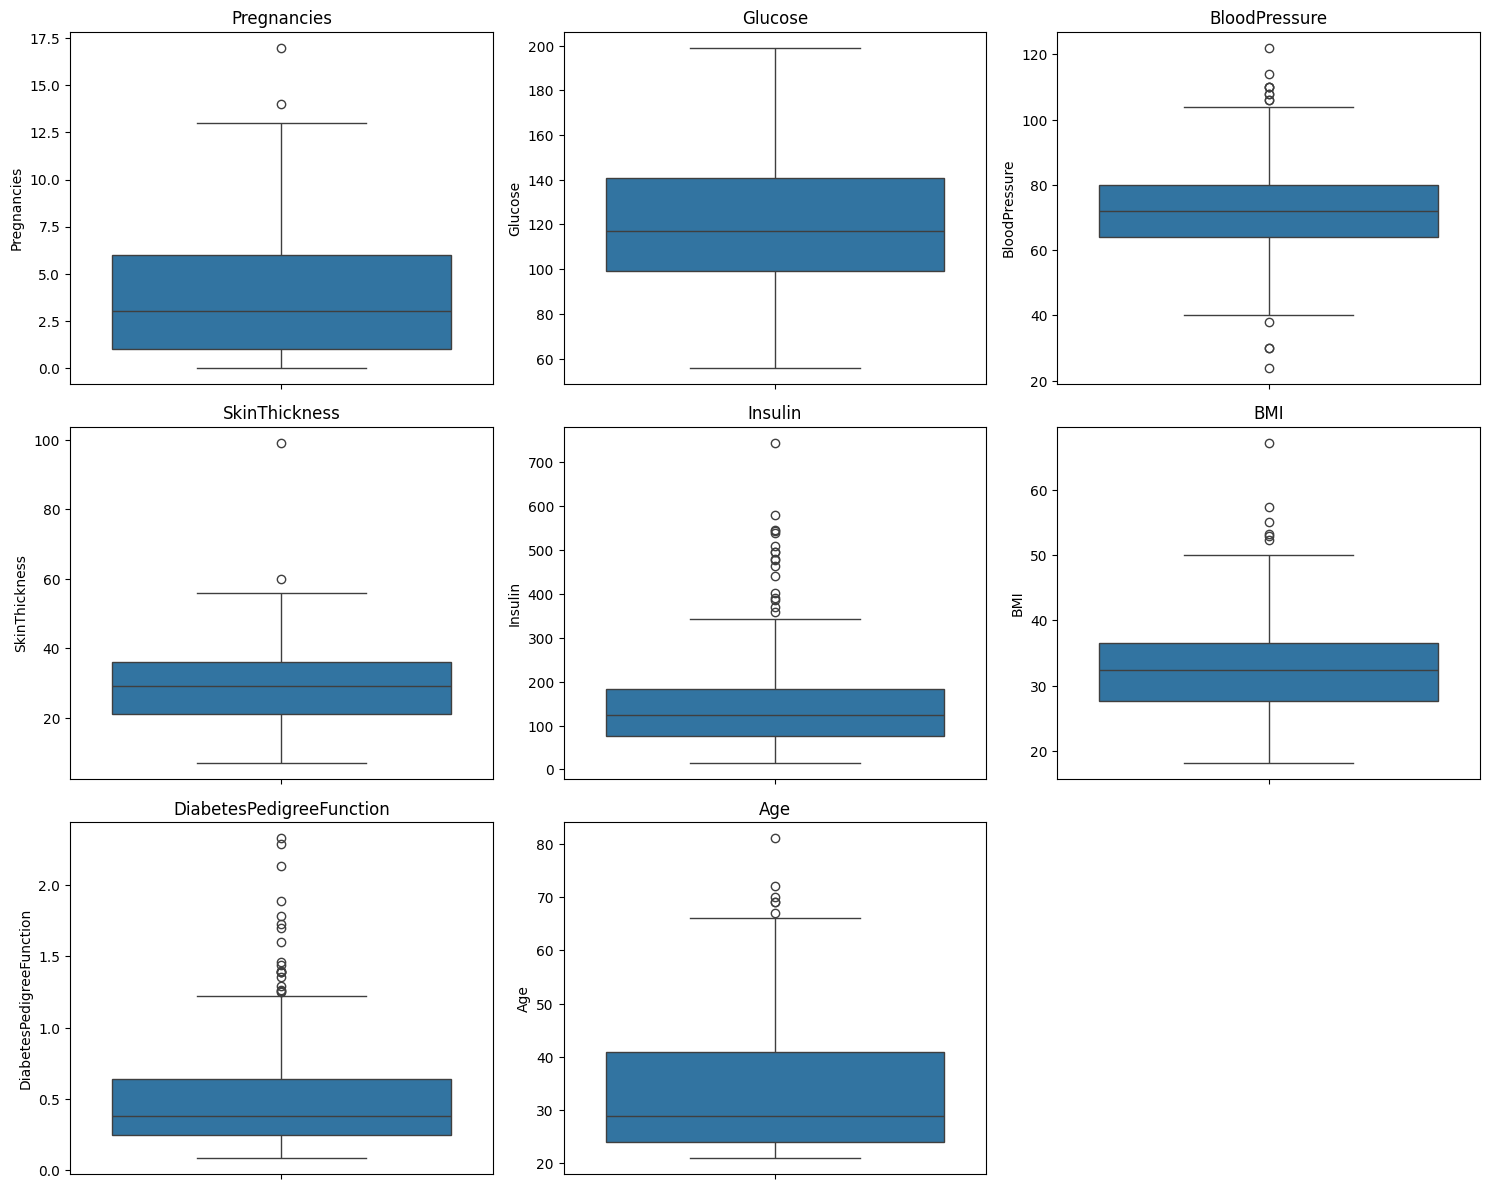

In [17]:
numeric_cols = x_train.select_dtypes(include='number').columns

n = len(numeric_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=x_train[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('figures/diabetes_outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
def count_outliers_iqr(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

outlier_counts = x_train.apply(count_outliers_iqr)
outlier_pct    = (outlier_counts / len(x_train) * 100).round(2)

print(pd.DataFrame({'count': outlier_counts, 'pct': outlier_pct})
        .sort_values('count', ascending=False))

                          count   pct
DiabetesPedigreeFunction     19  3.09
Insulin                      17  2.77
BloodPressure                13  2.12
BMI                           6  0.98
Age                           6  0.98
Pregnancies                   2  0.33
SkinThickness                 2  0.33
Glucose                       0  0.00


Insulin has the most outliers by far — the extreme values are probably real though, very high insulin is a legitimate clinical reading.

In [19]:
train_set, val_set = train_test_split(train_set, test_size=.2,
                                      stratify=train_set['Outcome'],
                                      random_state=42)

In [20]:
y_train      = np.ravel(train_set[['Outcome']])
x_train      = train_set.drop(columns=['Outcome'])

y_validation = np.ravel(val_set[['Outcome']])
x_validation = val_set.drop(columns=['Outcome'])

y_test       = np.ravel(test_set[['Outcome']])
x_test       = test_set.drop(columns=['Outcome'])

In [21]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
216,5,109.0,62.0,41.0,129.0,35.8,0.514,25
498,7,195.0,70.0,33.0,145.0,25.1,0.163,55
550,1,116.0,70.0,28.0,NaN,27.4,0.204,21
217,6,125.0,68.0,30.0,120.0,30.0,0.464,32
729,2,92.0,52.0,NaN,NaN,30.1,0.141,22
...,...,...,...,...,...,...,...,...
676,9,156.0,86.0,NaN,NaN,24.8,0.230,53
193,11,135.0,NaN,NaN,NaN,52.3,0.578,40
521,3,124.0,80.0,33.0,130.0,33.2,0.305,26
67,2,109.0,92.0,NaN,NaN,42.7,0.845,54


In [22]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

numeric_cols = x_train.select_dtypes(include='number').columns

_pipeline_numeric = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())

# Pipeline 1: impute then scale
preprocessing_standard = ColumnTransformer([
    ('num', _pipeline_numeric, numeric_cols)
])

# Pipeline 2: add BMI^2 and BMI*Glucose as extra features
def _add_bmi_glucose_interactions(X):
    bmi     = X[:, 0:1]
    glucose = X[:, 1:2]
    return np.hstack([bmi, glucose, bmi**2, bmi * glucose])

def _interaction_names(ft, names_in):
    return ['BMI', 'Glucose', 'BMI_sq', 'BMI_x_Glucose']

_pipeline_bmi_glucose = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    FunctionTransformer(func=_add_bmi_glucose_interactions, feature_names_out=_interaction_names)
)

remaining_cols = [c for c in numeric_cols if c not in ['BMI', 'Glucose']]

preprocessing_interactions = ColumnTransformer([
    ('bmi_gluc', _pipeline_bmi_glucose, ['BMI', 'Glucose']),
    ('num',      _pipeline_numeric,     remaining_cols)
])

# Pipeline 3: degree-2 polynomial expansion
_pipeline_poly = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
)

preprocessing_poly = ColumnTransformer([
    ('num_poly', _pipeline_poly, numeric_cols)
])

all three pipelines start with median imputation since Insulin is nearly half missing. the interaction pipeline adds BMI^2 and BMI*Glucose rather than compressing features — the BMI-glucose combination is specifically what makes this diabetes dataset interesting.

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ('preprocessor', preprocessing_standard),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

param_grid = [
    {
        'preprocessor': [preprocessing_standard, preprocessing_interactions, preprocessing_poly],
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear'],
    },
    {
        'preprocessor': [preprocessing_standard, preprocessing_interactions, preprocessing_poly],
        'model__penalty': ['elasticnet'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__l1_ratio': [0.25, 0.5, 0.75],
        'model__solver': ['saga'],
    },
]

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

lr_grid.fit(x_train, y_train)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\samue\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear'], 'preprocessor': [ColumnTransfo...type='str'))]), ColumnTransfo...on', 'Age'])]), ...]}, {'model__C': [0.001, 0.01, ...], 'model__l1_ratio': [0.25, 0.5, ...], 'model__penalty': ['elasticnet'], 'model__solver': ['saga'], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [24]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

best_lr   = lr_grid.best_estimator_
lr_proba  = best_lr.predict_proba(x_validation)[:, 1]
lr_pred   = best_lr.predict(x_validation)

print(f'Best params:  {lr_grid.best_params_}')
print(f'Best CV AUC:  {lr_grid.best_score_:.4f}')
print(f'Val AUC:      {roc_auc_score(y_validation, lr_proba):.4f}')
print(f'Val Accuracy: {accuracy_score(y_validation, lr_pred):.4f}')
print(f'Val F1:       {f1_score(y_validation, lr_pred):.4f}')

Best params:  {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'preprocessor': ColumnTransformer(transformers=[('num_poly',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler()),
                                                 ('polynomialfeatures',
                                                  PolynomialFeatures(include_bias=False))]),
                                 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='str'))])}
Best CV AUC:  0.8373
Val AUC:      0.8712
Val Accuracy: 0.7886
Val F1:       0.6750


training is basically instant. the poly preprocessing seems to help logistic regression more than the interaction terms alone.

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

# probability=True enables predict_proba via Platt scaling — slower but needed for AUC and calibration
svc_pipe = Pipeline([
    ('preprocessor', preprocessing_standard),
    ('model', SVC(probability=True, random_state=42, cache_size=500)),
])

svc_distributions = [
    {
        'preprocessor': [preprocessing_standard, preprocessing_interactions, preprocessing_poly],
        'model__kernel': ['rbf'],
        'model__C':      loguniform(1e-2, 1e3),
        'model__gamma':  loguniform(1e-4, 1e1),
    },
    {
        'preprocessor': [preprocessing_standard, preprocessing_interactions, preprocessing_poly],
        'model__kernel': ['linear'],
        'model__C':      loguniform(1e-2, 1e3),
    },
    {
        'preprocessor': [preprocessing_standard, preprocessing_interactions, preprocessing_poly],
        'model__kernel': ['poly'],
        'model__degree': [2, 3],
        'model__C':      loguniform(1e-2, 1e3),
        'model__gamma':  loguniform(1e-4, 1e1),
        'model__coef0':  uniform(0, 5),
    },
]

svc_search = RandomizedSearchCV(
    svc_pipe,
    param_distributions=svc_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

svc_search.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model__C': <scipy.stats....001DF63DE2480>, 'model__gamma': <scipy.stats....001DF65F1EB40>, 'model__kernel': ['rbf'], 'preprocessor': [ColumnTransfo...type='str'))]), ColumnTransfo...on', 'Age'])]), ...]}, {'model__C': <scipy.stats....001DF663506B0>, 'model__kernel': ['linear'], 'preprocessor': [ColumnTransfo...type='str'))]), ColumnTransfo...on', 'Age'])]), ...]}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFo

In [26]:
best_svc  = svc_search.best_estimator_
svc_proba = best_svc.predict_proba(x_validation)[:, 1]
svc_pred  = best_svc.predict(x_validation)

print(f'Best CV AUC:  {svc_search.best_score_:.4f}')
print(f'Val AUC:      {roc_auc_score(y_validation, svc_proba):.4f}')
print(f'Val Accuracy: {accuracy_score(y_validation, svc_pred):.4f}')
print(f'Val F1:       {f1_score(y_validation, svc_pred):.4f}')

Best CV AUC:  0.8368
Val AUC:      0.8727
Val Accuracy: 0.8049
Val F1:       0.6923


In [27]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_pipe = Pipeline([
    ('preprocessor', preprocessing_standard),
    ('model', HistGradientBoostingClassifier(random_state=42)),
])

hgb_distributions = {
    'preprocessor':            [preprocessing_standard, preprocessing_interactions, preprocessing_poly],
    'model__learning_rate':    loguniform(0.01, 0.3),
    'model__max_iter':         [200, 500, 1000],
    'model__max_depth':        [None, 3, 5, 7],
    'model__min_samples_leaf': [5, 10, 20],
    'model__l2_regularization': loguniform(1e-4, 1e1),
    'model__max_leaf_nodes':   [15, 31, 63],
}

hgb_search = RandomizedSearchCV(
    hgb_pipe,
    param_distributions=hgb_distributions,
    n_iter=60,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

hgb_search.fit(x_train, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__l2_regularization': <scipy.stats....001DF663352B0>, 'model__learning_rate': <scipy.stats....001DF662BDD90>, 'model__max_depth': [None, 3, ...], 'model__max_iter': [200, 500, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for

In [28]:
best_hgb  = hgb_search.best_estimator_
hgb_proba = best_hgb.predict_proba(x_validation)[:, 1]
hgb_pred  = best_hgb.predict(x_validation)

print(f'Best CV AUC:  {hgb_search.best_score_:.4f}')
print(f'Val AUC:      {roc_auc_score(y_validation, hgb_proba):.4f}')
print(f'Val Accuracy: {accuracy_score(y_validation, hgb_pred):.4f}')
print(f'Val F1:       {f1_score(y_validation, hgb_pred):.4f}')

Best CV AUC:  0.8252
Val AUC:      0.8555
Val Accuracy: 0.7805
Val F1:       0.6824


In [29]:
named_models = {
    'LogisticRegression': (best_lr,  lr_grid.best_score_,  lr_proba,  lr_pred),
    'SVC':                (best_svc, svc_search.best_score_, svc_proba, svc_pred),
    'HistGBoosting':      (best_hgb, hgb_search.best_score_, hgb_proba, hgb_pred),
}

rows = []
for name, (model, cv_auc, proba, pred) in named_models.items():
    rows.append({
        'Model':   name,
        'CV AUC':  cv_auc,
        'Val AUC': roc_auc_score(y_validation, proba),
        'Val Acc': accuracy_score(y_validation, pred),
        'Val F1':  f1_score(y_validation, pred),
    })

summary = pd.DataFrame(rows).sort_values('Val AUC', ascending=False).reset_index(drop=True)

with pd.option_context('display.float_format', '{:.4f}'.format):
    print(summary.to_string(index=False))

             Model  CV AUC  Val AUC  Val Acc  Val F1
               SVC  0.8368   0.8727   0.8049  0.6923
LogisticRegression  0.8373   0.8712   0.7886  0.6750
     HistGBoosting  0.8252   0.8555   0.7805  0.6824


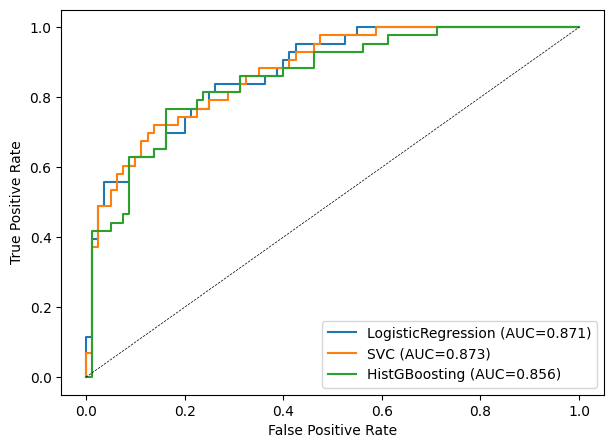

In [30]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))
for name, (model, _, proba, _) in named_models.items():
    fpr, tpr, _ = roc_curve(y_validation, proba)
    auc = roc_auc_score(y_validation, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.savefig('figures/diabetes_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

all three models are close in AUC. SVC comes out on top with the highest validation AUC (0.8727) and accuracy (0.8049) — the RBF kernel handles the nonlinear decision boundary better than the linear models and generalizes more cleanly than the boosted trees on this dataset size.

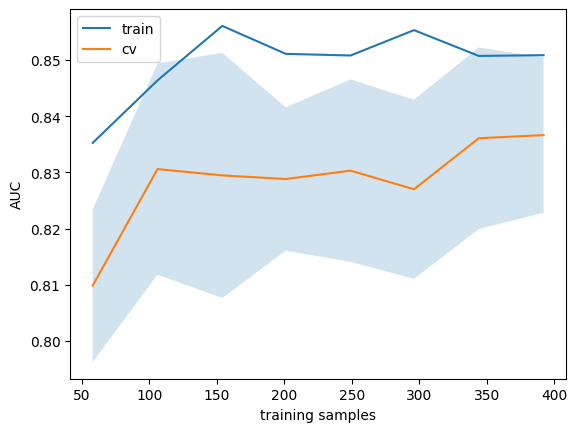

In [31]:
from sklearn.model_selection import learning_curve

best_final = best_svc

sizes, tr_sc, va_sc = learning_curve(
    best_final, x_train, y_train,
    train_sizes=np.linspace(0.15, 1.0, 8),
    scoring='roc_auc',
    cv=5, n_jobs=-1
)

plt.plot(sizes, tr_sc.mean(axis=1), label='train')
plt.plot(sizes, va_sc.mean(axis=1), label='cv')
plt.fill_between(sizes,
    va_sc.mean(axis=1) - va_sc.std(axis=1),
    va_sc.mean(axis=1) + va_sc.std(axis=1),
    alpha=0.2)
plt.xlabel('training samples')
plt.ylabel('AUC')
plt.legend()
plt.savefig('figures/diabetes_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

CV AUC is still climbing slowly at the full training size. More data would likely help more than further hyperparameter tuning at this point.

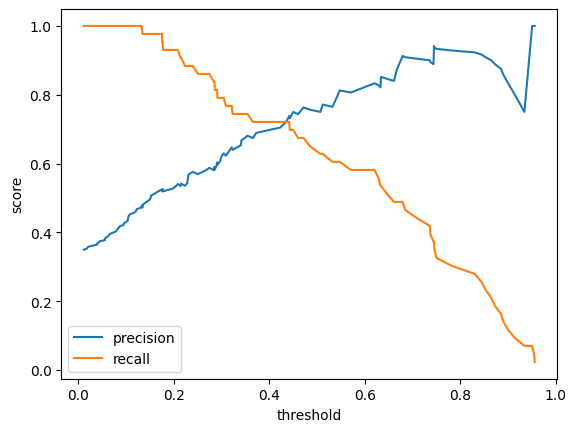

In [32]:
from sklearn.metrics import precision_recall_curve

best_proba = best_final.predict_proba(x_validation)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_validation, best_proba)

plt.plot(thresholds, prec[:-1], label='precision')
plt.plot(thresholds, rec[:-1], label='recall')
plt.xlabel('threshold')
plt.ylabel('score')
plt.legend()
plt.savefig('figures/diabetes_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

default 0.5 is roughly the crossover. for a screening tool where missing a diabetic patient is worse than a false alarm, dropping to ~0.35-0.40 gets meaningfully more recall.

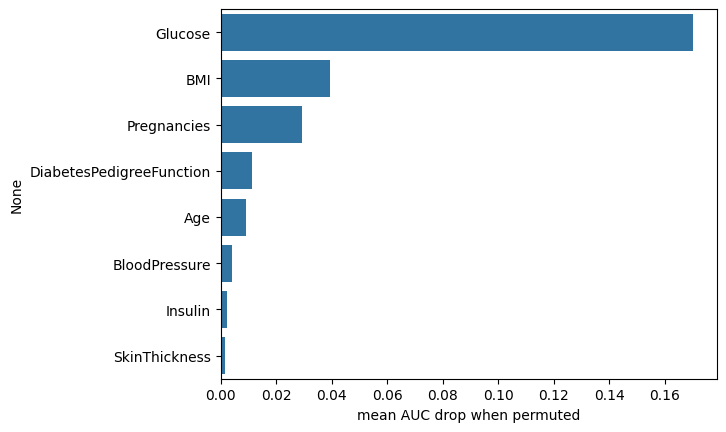

In [33]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_final, x_test, y_test,
    n_repeats=30, random_state=42,
    scoring='roc_auc'
)

imp = pd.Series(r.importances_mean, index=x_train.columns).sort_values(ascending=False)

sns.barplot(x=imp.values, y=imp.index)
plt.xlabel('mean AUC drop when permuted')
plt.savefig('figures/diabetes_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Glucose dominates by a wide margin as expected. BMI and Age both matter. Insulin and SkinThickness barely register despite being clinically relevant — the high missing-data rate limits their signal.

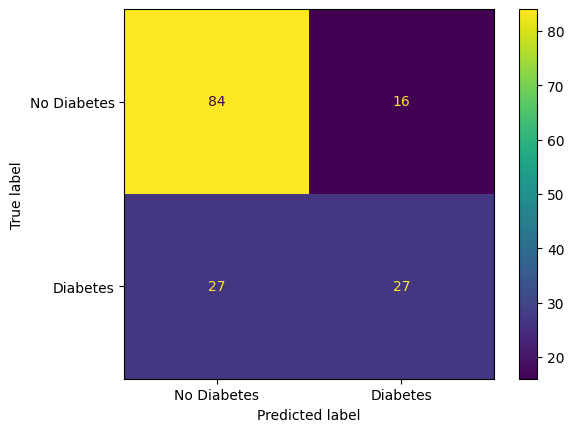

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_final.predict(x_test)

cm   = confusion_matrix(y_test, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])

disp.plot()
plt.savefig('figures/diabetes_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

The SVC catches more true positives, but still misses a meaningful number of diabetic patients (false negatives). For a screening tool where failing to flag a diabetic is the costlier mistake, lowering the decision threshold from 0.5 toward ~0.35-0.40 would trade some precision for higher recall.

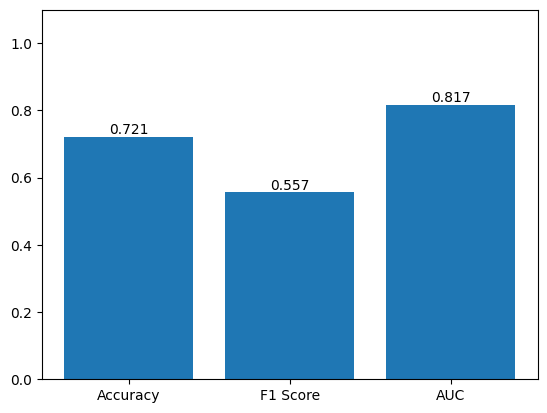

In [35]:
test_proba = best_final.predict_proba(x_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = f1_score(y_test, y_pred, pos_label=1, average='binary')
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, test_proba)

fig, ax = plt.subplots()
bars = ax.bar(['Accuracy', 'F1 Score', 'AUC'], [acc, f1, auc])
ax.bar_label(bars, fmt='%.3f')
ax.set_ylim(0, 1.1)
plt.savefig('figures/diabetes_final_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

~72% accuracy, AUC around 0.82. Glucose is doing most of the work. Still not horrible results